# Average and Median Spectrograms of Saturn's Radio flux using over entire Cassini mission duration.

In [1]:
import numpy as np
import xarray as xr
import pandas as pd

import matplotlib.colors as mp_colors
import matplotlib.pyplot as plt

C:\Users\Local Admin\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
skr_poly_flux_all_fp = '../data/calculated/poly_flux_combined.ncdf'
ephemeris_fp = '../data/calculated/20040101000000_20170915115700_ephemeris.csv'

Read the polygon's masked flux

In [3]:
ds = xr.open_dataset(skr_poly_flux_all_fp, engine='netcdf4')  # This file is all the masked polygon flux from all years combined together, yearly files generated from get_polygon_flux.ipynb

Create a panda dataframe with frequency values as columns

In [4]:
df = pd.DataFrame(ds["flux"].T, columns=ds["frequency"])
df["Universal Time"] = ds["time"]  # Rename column time to Universal Time
#df

Read the ephemeris data as a pandas dataframe

In [5]:
df_ephemeris = pd.read_csv(ephemeris_fp)
df_ephemeris = df_ephemeris.rename(columns={'start': 'Universal Time'})  # Rename datetime column to Universal Time
df_ephemeris["Universal Time"] = np.array(df_ephemeris['Universal Time'], dtype='datetime64')  # Convert strings to datetime64 format
#df_ephemeris

Merge both dataframes on their Universal time column

In [6]:
df_all = df.merge(df_ephemeris, on='Universal Time')
#df_all

We can now bin the values with respect to local time (subLST column)

In [7]:
#bins = np.arange(0, 24.2, 0.2)  # 0 to 24hr with an interval of 12 min
#df_all['local_time'] = pd.cut(df_all['subLST'], bins=bins) # Create and add bin column to the entire dataframe

bins = np.arange(-90, 90, 1)  # 0 to 24hr with an interval of 12 min
df_all['Latitude'] = pd.cut(df_all['subLat'], bins=bins) # Create and add bin column to the entire dataframe
#df_all

Group values by bins and take their mean/median per frequency per bin

In [8]:
#df_mean = df_all.groupby('local_time').mean()
#df_median = df_all.groupby('local_time').median()

df_mean = df_all.groupby('Latitude').mean()
df_median = df_all.groupby('Latitude').median()



C:\Users\Local Admin\AppData\Local\Temp\ipykernel_17820\1065447569.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_mean = df_all.groupby('Latitude').mean()
C:\Users\Local Admin\AppData\Local\Temp\ipykernel_17820\1065447569.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_median = df_all.groupby('Latitude').median()


The first 48 columns are all the frequency-flux values

In [9]:
mean_flux = df_mean.iloc[:, :48].to_numpy()
median_flux = df_median.iloc[:, :48].to_numpy()

Plots

In [10]:
bins

array([-90, -89, -88, -87, -86, -85, -84, -83, -82, -81, -80, -79, -78,
       -77, -76, -75, -74, -73, -72, -71, -70, -69, -68, -67, -66, -65,
       -64, -63, -62, -61, -60, -59, -58, -57, -56, -55, -54, -53, -52,
       -51, -50, -49, -48, -47, -46, -45, -44, -43, -42, -41, -40, -39,
       -38, -37, -36, -35, -34, -33, -32, -31, -30, -29, -28, -27, -26,
       -25, -24, -23, -22, -21, -20, -19, -18, -17, -16, -15, -14, -13,
       -12, -11, -10,  -9,  -8,  -7,  -6,  -5,  -4,  -3,  -2,  -1,   0,
         1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,  13,
        14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,  26,
        27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,  39,
        40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,  52,
        53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,  65,
        66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,  78,
        79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89])

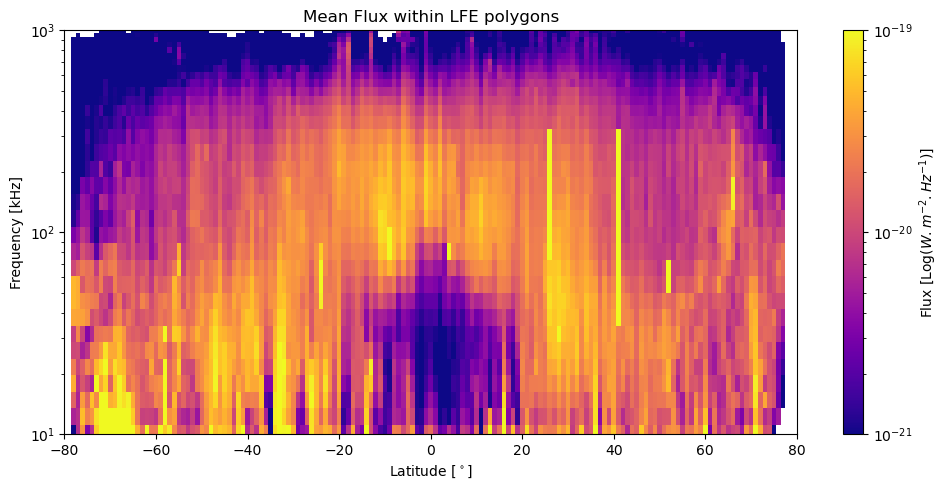

In [13]:
fig = plt.figure(figsize=(10,5), dpi=100)
ax = fig.add_subplot()

#norm = mp_colors.LogNorm()
norm = mp_colors.LogNorm(vmin=1e-21, vmax=1e-19)
cbar = ax.pcolormesh(bins[:-1], ds["frequency"], mean_flux.T, norm=norm, cmap='plasma')

fig.colorbar(cbar, label=r'Flux [Log($W.m^{-2}.Hz^{-1}$)]')

#ax.set_xticks(bins[:-1:10])
#ax.set_xticks(bins[:-1], minor=True) # Check minute ticks to macth bins
#ax.set_xticks(bins[:-1])

#ax.xaxis.set_major_formatter('{x:.0f}:00')

ax.set_yscale('log')
ax.set_ylim([1e1,1e3])
ax.set_xlim([-80,80])
ax.set_xlabel('Latitude [$^\circ$]')
ax.set_ylabel('Frequency [kHz]')
ax.set_title('Mean Flux within LFE polygons')

plt.tight_layout()    
plt.savefig("Mean_LFE_spectrogram_Latitude.pdf",format="pdf")
plt.show()    

think about data distribution

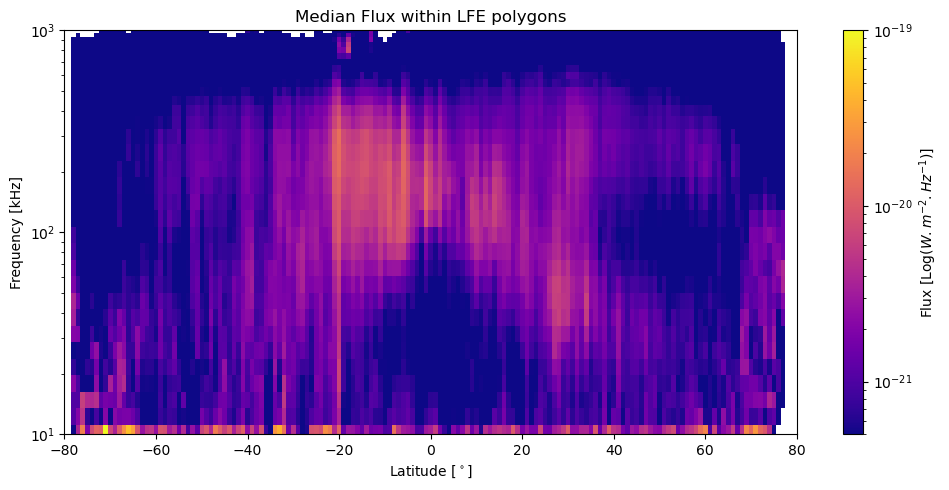

In [15]:
fig = plt.figure(figsize=(10,5), dpi=100)
ax = fig.add_subplot()

#norm = mp_colors.LogNorm()
#norm = mp_colors.LogNorm(vmin=1e-21, vmax=1e-19)
norm = mp_colors.LogNorm(vmin=5e-22, vmax=1e-19)

cbar = ax.pcolormesh(bins[:-1], ds["frequency"], median_flux.T, norm=norm, cmap='plasma')

fig.colorbar(cbar, label=r'Flux [Log($W.m^{-2}.Hz^{-1}$)]')

#ax.set_xticks(bins[:-1:10])
#ax.set_xticks(bins[:-1], minor=True) # Check minute ticks to macth bins
#ax.set_xticks(bins[:-1])

#ax.xaxis.set_major_formatter('{x:.0f}:00')

ax.set_yscale('log')
ax.set_ylim([1e1,1e3])
ax.set_xlim([-80,80])
ax.set_xlabel('Latitude [$^\circ$]')
ax.set_ylabel('Frequency [kHz]')
ax.set_title('Median Flux within LFE polygons')

plt.tight_layout()    
plt.savefig("Median_LFE_spectrogram_Latitude.pdf",format="pdf")
plt.show()    

